In [18]:
import optuna
import pandas as pd

study_name='optuna_results'  # Un nome per il tuo studio
storage_path='sqlite:///optuna_results.db'  # Nome del file dove salvare
study = optuna.load_study(study_name=study_name, storage=storage_path)

df = study.trials_dataframe()

df.columns = [c.replace('user_attrs_', '').replace('params_', '') for c in df.columns]

df = df.sort_values(by="value", ascending=False)

print(f"Estrazione completata! Totale trial analizzati: {len(df)}")
df

Estrazione completata! Totale trial analizzati: 93

 best 5 trials:


,number,value,datetime_start,datetime_complete,duration,batch_size,dropout_rate,lr,num_heads,patience,...,test_mean_Sn,test_mean_Sp,test_std_ACC,test_std_AUROC,test_std_F1,test_std_MCC,test_std_PR_AUC,test_std_Sn,test_std_Sp,state
1,1,0.777878,2026-02-05 11:13:43.528066,2026-02-05 11:19:21.350820,0 days 00:05:37.822754,32,0.383229,0.000002,5,10,...,0.903643,0.864348,0.005703,0.004809,0.007084,0.011935,0.009470,0.017846,0.006679,COMPLETE
6,6,0.764070,2026-02-05 11:31:34.176567,2026-02-05 11:34:54.654414,0 days 00:03:20.477847,64,0.339160,0.000006,4,14,...,0.901891,0.860435,0.004313,0.003029,0.004856,0.008961,0.007482,0.011627,0.006929,COMPLETE
50,50,0.763360,2026-02-05 14:13:00.492931,2026-02-05 14:15:52.527372,0 days 00:02:52.034441,32,0.435117,0.000005,4,7,...,0.895292,0.871739,0.003644,0.004128,0.004020,0.007373,0.009600,0.015895,0.015616,COMPLETE
11,11,0.762547,2026-02-05 11:45:47.590790,2026-02-05 11:50:15.530875,0 days 00:04:27.940085,64,0.445974,0.000003,4,12,...,0.897928,0.865652,0.004898,0.005382,0.005992,0.010201,0.010873,0.017651,0.011939,COMPLETE
2,2,0.762192,2026-02-05 11:19:21.358576,2026-02-05 11:21:22.894063,0 days 00:02:01.535487,64,0.272778,0.000008,5,7,...,0.891337,0.868696,0.005434,0.004961,0.006782,0.011258,0.011300,0.019278,0.011388,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,3,0.722900,2026-02-05 11:21:22.901837,2026-02-05 11:23:39.425648,0 days 00:02:16.523811,32,0.305694,0.000079,8,13,...,0.881634,0.863478,0.012560,0.003563,0.017541,0.024756,0.005565,0.048191,0.022982,COMPLETE
47,47,0.720401,2026-02-05 14:04:24.278218,2026-02-05 14:05:34.587601,0 days 00:01:10.309383,64,0.327439,0.000017,4,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRUNED
81,81,0.719115,2026-02-05 16:09:48.141739,2026-02-05 16:11:13.077562,0 days 00:01:24.935823,64,0.452717,0.000024,5,13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRUNED
8,8,0.714637,2026-02-05 11:36:36.771062,2026-02-05 11:38:21.207634,0 days 00:01:44.436572,32,0.102209,0.000005,4,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRUNED


=== BEST TRIAL INFO ===
Objective Val: 0.7779



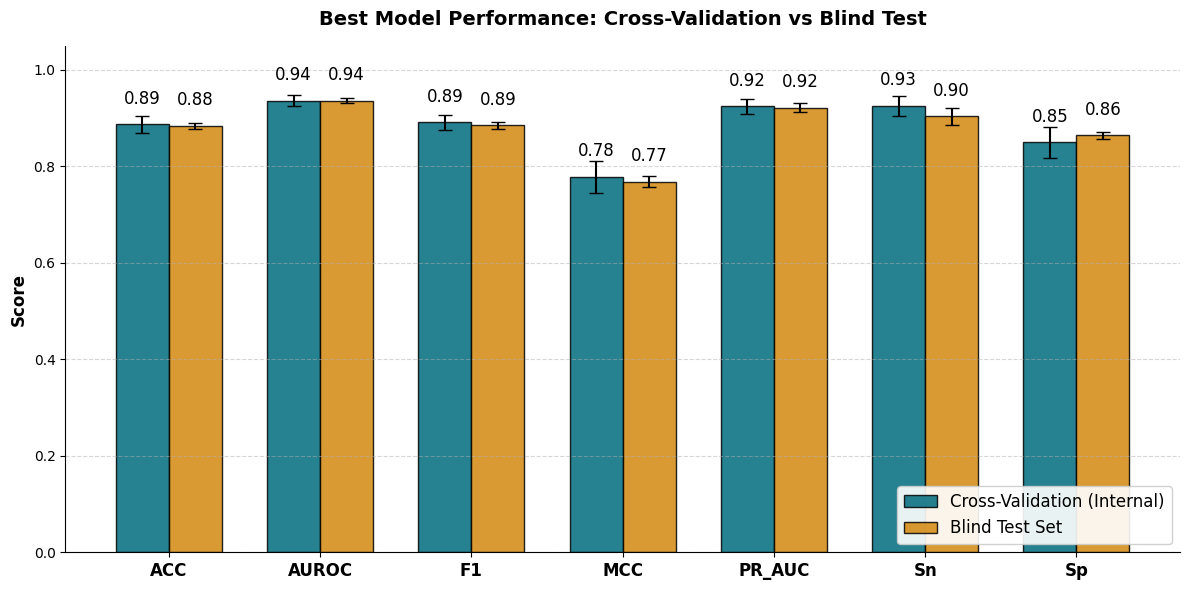

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_best_trial_info(df):
    """
    Estrae il miglior trial dal DataFrame di Optuna e plotta 
    il confronto tra le metriche di Cross-Validation e Test.
    """
    # 1. Trova il trial migliore (quello con il 'value' massimo)
    best_trial = df.loc[df['value'].idxmax()]
    
    # --- STAMPA RECAP TESTUALE ---
    print("=== BEST TRIAL INFO ===")
    print(f"Objective Val: {best_trial['value']:.4f}")
    params = ['batch_size', 'dropout_rate', 'lr', 'num_heads', 'patience', 'weight_decay']
    for p in params:
        if p in best_trial:
            # Formattazione per la learning rate (notazione scientifica)
            val = best_trial[p]
            if p in ['lr', 'weight_decay']:
                print(f"  - {p:<15}: {val:.2e}")
            elif isinstance(val, float):
                print(f"  - {p:<15}: {val:.4f}")
            else:
                print(f"  - {p:<15}: {val}")
    print("===========================\n")

    # --- PREPARAZIONE DATI PER IL PLOT ---
    metrics = ['ACC', 'AUROC', 'F1', 'MCC', 'PR_AUC', 'Sn', 'Sp']
    
    internal_means = [best_trial[f'user_attrs_internal_mean_{m}'] for m in metrics]
    internal_stds  = [best_trial[f'user_attrs_internal_std_{m}'] for m in metrics]
    
    test_means = [best_trial[f'user_attrs_test_mean_{m}'] for m in metrics]
    test_stds  = [best_trial[f'user_attrs_test_std_{m}'] for m in metrics]

    # --- CREAZIONE BAR PLOT ---
    x = np.arange(len(metrics))  # Posizioni delle etichette
    width = 0.35                 # Spessore delle barre

    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Barre per CV (Internal)
    rects1 = ax.bar(x - width/2, internal_means, width, 
                    yerr=internal_stds, capsize=5, 
                    label='Cross-Validation (Internal)', 
                    color='#006B7D', edgecolor='black', alpha=0.85)
    
    # Barre per Test Set (Holdout)
    rects2 = ax.bar(x + width/2, test_means, width, 
                    yerr=test_stds, capsize=5, 
                    label='Blind Test Set', 
                    color='#D4880F', edgecolor='black', alpha=0.85)

    # --- STILE E COSMETICA ---
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('Best Model Performance: Cross-Validation vs Blind Test', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.05) # I punteggi vanno da 0 a 1
    ax.legend(loc='lower right', fontsize=12, framealpha=0.9)
    
    # Griglia orizzontale leggera
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Funzione per aggiungere le etichette di testo sopra le barre
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 12),  # 8 punti di offset verticale
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=12, rotation=0)

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.savefig('best_trial_performance.png', dpi=300, bbox_inches='tight')
    plt.show()


df = study.trials_dataframe()
plot_best_trial_info(df)
